In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
defensive_duels = pd.read_parquet("data/defensive_duels_valued.parquet")
matches = pd.read_parquet("data/matches.parquet")
leagues = pd.read_parquet("data/leagues.parquet")

In [28]:
defensive_duels["goal_conceded"] = defensive_duels.outcome == -1

In [29]:
all_events = pd.read_parquet("data/all_events.parquet")

In [30]:
xg_for = all_events.groupby(["matchId", "team_id"])["shot_xg"].sum()
match_total = all_events.groupby("matchId")["shot_xg"].sum()
xg_against = match_total - xg_for  # broadcasts over the team_id level

In [31]:
defensive_duel_total_values = defensive_duels.groupby(["matchId","team_id"])[["goal_conceded","duel_value"]].sum()
defensive_duels_avg_conceded = defensive_duels.groupby(["matchId","team_id"])[["duel_value"]].mean()

In [32]:
duel_win_rates = defensive_duels.groupby(["matchId","team_id"])[["groundDuel_recoveredPossession","groundDuel_stoppedProgress"]].mean()
duel_win_counts = defensive_duels.groupby(["matchId","team_id"])[["groundDuel_recoveredPossession","groundDuel_stoppedProgress"]].sum()

In [33]:
team_match_stats = (
    defensive_duel_total_values
    .rename(columns={"duel_value": "duel_value_sum"})
    .join(defensive_duels_avg_conceded.rename(columns={"duel_value": "duel_value_mean"}))
    .join(duel_win_rates.add_suffix("_rate"))
    .join(duel_win_counts.add_suffix("_count"))
    .join(xg_against.rename("xg_against"))
)

In [34]:
team_match_stats

goal_conceded  duel_value_sum  duel_value_mean  \
matchId team_id                                                   
5219995 28072                2       -0.127225        -0.002194   
        28443                2       -0.173822        -0.002519   
5219996 28320                2       -0.137106        -0.003116   
        28437                0        0.069871         0.001426   
5219997 27017                3        0.124368         0.001352   
...                        ...             ...              ...   
5663809 27938                0       -0.042068        -0.000628   
5663810 28240                2        0.047864         0.000563   
        28355                1        0.279849         0.004305   
5663811 27938                3       -0.078304        -0.001073   
        28355                0        0.083137         0.001732   

                 groundDuel_recoveredPossession_rate  \
matchId team_id                                        
5219995 28072                               0.224138   
        28443                               0.275362   
5219996 28320                               0.136364   
        28437                               0.285714   
5219997 27017                               0.258065   
...                                              ...   
5663809 27938                               0.268657   
5663810 28240                               0.235294   
        28355                               0.215385   
5663811 27938                               0.178082   
        28355                               0.354167   

                 groundDuel_stoppedProgress_rate  \
matchId team_id                                    
5219995 28072                           0.396552   
        28443                           0.405797   
5219996 28320                           0.409091   
        28437                           0.265306   
5219997 27017                           0.408602   
...                                          ...   
5663809 27938                           0.343284   
5663810 28240                           0.470588   
        28355                           0.538462   
5663811 27938                           0.438356   
        28355                           0.354167   

                 groundDuel_recoveredPossession_count  \
matchId team_id                                         
5219995 28072                                      13   
        28443                                      19   
5219996 28320                                       6   
        28437                                      14   
5219997 27017                                      24   
...                                               ...   
5663809 27938                                      18   
5663810 28240                                      20   
        28355                                      14   
5663811 27938                                      13   
        28355                                      17   

                 groundDuel_stoppedProgress_count  xg_against  
matchId team_id                                                
5219995 28072                                  23    2.242680  
        28443                                  28    1.179476  
5219996 28320                                  18    1.006020  
        28437                                  13    1.255291  
5219997 27017                                  38    1.318130  
...                                           ...         ...  
5663809 27938                                  23    2.214407  
5663810 28240                                  40    1.107061  
        28355                                  35    1.648892  
5663811 27938                                  32    1.593373  
        28355                                  17    0.984961  

[14590 rows x 8 columns]

<Axes: xlabel='duel_value_mean', ylabel='goal_conceded'>

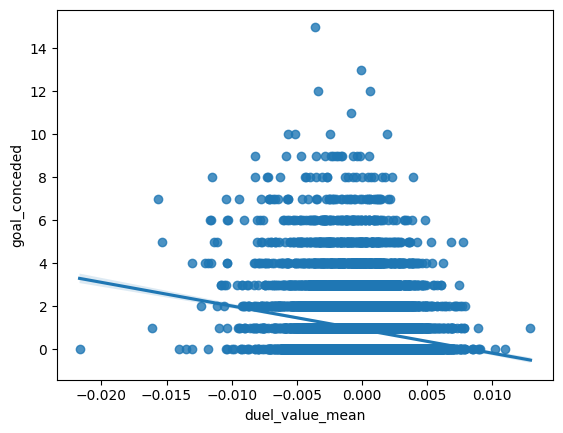

In [35]:
sns.regplot(data=team_match_stats.reset_index(), x="duel_value_mean", y="goal_conceded")

In [36]:
import statsmodels.api as sm
y = team_match_stats["goal_conceded"]
rows = []
for col in team_match_stats.columns.drop("goal_conceded"):
    x = sm.add_constant(team_match_stats[col])
    m = sm.OLS(y, x).fit()
    rows.append({
        "predictor": col,
        "slope": m.params[col],
        "std_err": m.bse[col],
        "t": m.tvalues[col],
        "p_value": m.pvalues[col],
        "r_squared": m.rsquared,
        "n": int(m.nobs),
    })
univariate_results = pd.DataFrame(rows).sort_values("r_squared", ascending=False).reset_index(drop=True)
univariate_results

,predictor,slope,std_err,t,p_value,r_squared,n
0,xg_against,0.557372,0.011388,48.944421,0.000000e+00,0.141052,14590
1,duel_value_sum,-2.061264,0.078613,-26.220486,4.093766e-148,0.045008,14590
2,duel_value_mean,-109.813930,4.387328,-25.029795,2.048101e-135,0.041177,14590
3,groundDuel_stoppedProgress_count,0.028785,0.001336,21.546089,2.178047e-101,0.030842,14590
4,groundDuel_recoveredPossession_rate,-2.846685,0.173206,-16.435272,3.711667e-60,0.018180,14590
5,groundDuel_recoveredPossession_count,0.020957,0.002394,8.752805,2.306549e-18,0.005224,14590
6,groundDuel_stoppedProgress_rate,0.036262,0.149478,0.242593,8.083242e-01,0.000004,14590


In [37]:
reg_games = pd.merge(leagues[~leagues.wyId.isin([43226,43049])][["wyId"]],matches[["wyId","competitionId","teams","winner","seasonId"]],left_on="wyId",right_on="competitionId")

In [38]:
import ast

m = reg_games[["seasonId", "teams", "winner"]].copy()
m["teams"] = m["teams"].apply(ast.literal_eval)
m = m.explode("teams")
m["team_id"] = m["teams"].astype(int)
m["win"] = m["team_id"] == m["winner"]
m["draw"] = m["winner"] == 0

season_win_rates = m.groupby(["seasonId", "team_id"]).agg(
    played=("win", "size"),
    wins=("win", "sum"),
    draws=("draw", "sum"),
)

season_win_rates["win_rate"] = season_win_rates["wins"] / season_win_rates["played"]

In [58]:
reg_match_ids = matches.loc[~matches.competitionId.isin([43226, 43049]), "wyId"]
season_by_match = matches.set_index("wyId")["seasonId"]

tms_reg = team_match_stats.loc[
    team_match_stats.index.get_level_values("matchId").isin(reg_match_ids)
].copy()
tms_reg["seasonId"] = tms_reg.index.get_level_values("matchId").map(season_by_match)

# Match-level sums roll up to season totals
sum_cols = [
    "duel_value_sum",
    "groundDuel_recoveredPossession_count",
    "groundDuel_stoppedProgress_count",
]
season_grp = tms_reg.groupby(["seasonId", "team_id"])
for c in sum_cols:
    season_win_rates[c] = season_grp[c].sum()

season_win_rates["goals_conceded_mean"] = season_grp["goal_conceded"].mean()

# Season-level rates and per-duel value mean computed from raw duels
# (weighted by total duels, not unweighted across matches)
duels_reg = defensive_duels[defensive_duels["matchId"].isin(reg_match_ids)].copy()
duels_reg["seasonId"] = duels_reg["matchId"].map(season_by_match)
duel_grp = duels_reg.groupby(["seasonId", "team_id"])

season_win_rates["duel_value_mean"] = duel_grp["duel_value"].mean()
season_win_rates["groundDuel_recoveredPossession_rate"] = duel_grp["groundDuel_recoveredPossession"].mean()
season_win_rates["groundDuel_stoppedProgress_rate"] = duel_grp["groundDuel_stoppedProgress"].mean()

season_win_rates = season_win_rates[season_win_rates.played > 8]

C:\Users\zcoch\AppData\Local\Temp\ipykernel_12604\4135375096.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  season_win_rates[c] = season_grp[c].sum()
C:\Users\zcoch\AppData\Local\Temp\ipykernel_12604\4135375096.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  season_win_rates["goals_conceded_mean"] = season_grp["goal_conceded"].mean()
C:\Users\zcoch\AppData\Local\Temp\ipykernel_12604\4135375096.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try u

In [59]:
season_win_rates

played  wins  draws  win_rate  duel_value_sum  \
seasonId team_id                                                  
188201   24424        11     8      2  0.727273        0.288114   
         24426         9     3      2  0.333333        0.188396   
         24487        11     5      1  0.454545       -0.767880   
         24488         9     3      1  0.333333       -0.204143   
         24494        10     5      3  0.500000        0.634448   
...                  ...   ...    ...       ...             ...   
191019   54991         9     5      1  0.555556        0.729314   
191037   24694         9     7      0  0.777778        0.767408   
         24697         9     7      2  0.777778        0.810705   
         24698         9     3      1  0.333333        0.112647   
         24699         9     3      1  0.333333        0.691717   

                  groundDuel_recoveredPossession_count  \
seasonId team_id                                         
188201   24424                                     153   
         24426                                     124   
         24487                                     105   
         24488                                     126   
         24494                                     182   
...                                                ...   
191019   54991                                     135   
191037   24694                                     116   
         24697                                     129   
         24698                                     126   
         24699                                     128   

                  groundDuel_stoppedProgress_count  goals_conceded_mean  \
seasonId team_id                                                          
188201   24424                                 198             0.090909   
         24426                                 219             1.000000   
         24487                                 205             0.636364   
         24488                                 218             0.888889   
         24494                                 276             0.200000   
...                                            ...                  ...   
191019   54991                                 227             0.555556   
191037   24694                                 175             0.333333   
         24697                                 223             0.222222   
         24698                                 228             0.222222   
         24699                                 273             1.555556   

                  duel_value_mean  groundDuel_recoveredPossession_rate  \
seasonId team_id                                                         
188201   24424           0.000514                             0.270796   
         24426           0.000350                             0.230483   
         24487          -0.001430                             0.195167   
         24488          -0.000350                             0.215753   
         24494           0.000929                             0.266082   
...                           ...                                  ...   
191019   54991           0.001416                             0.259117   
191037   24694           0.001943                             0.290727   
         24697           0.001651                             0.259036   
         24698           0.000212                             0.236398   
         24699           0.001195                             0.220310   

                  groundDuel_stoppedProgress_rate  
seasonId team_id                                   
188201   24424                           0.350442  
         24426                           0.407063  
         24487                           0.381041  
         24488                           0.373288  
         24494                           0.403509  
...                                           ...  
191019   54991                      

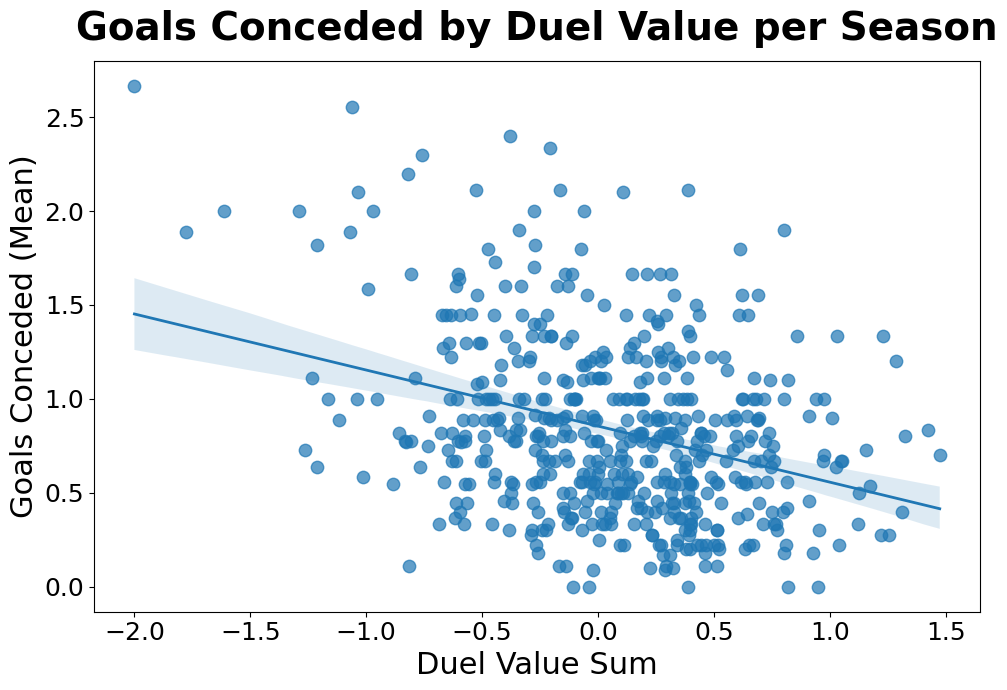

In [75]:
# Poster font sizes
TITLE_SIZE = 28
LABEL_SIZE = 22
TICK_SIZE = 18

fig, ax = plt.subplots(figsize=(10, 7))

sns.regplot(
    data=season_win_rates.reset_index(),
    x="duel_value_sum",
    y="goals_conceded_mean",
    ax=ax,
    scatter_kws={"s": 80, "alpha": 0.7},
    line_kws={"linewidth": 2}
)

ax.set_title("Goals Conceded by Duel Value per Season", fontsize=TITLE_SIZE, fontweight="bold", pad=15)
ax.set_xlabel("Duel Value Sum", fontsize=LABEL_SIZE)
ax.set_ylabel("Goals Conceded (Mean)", fontsize=LABEL_SIZE)
ax.tick_params(axis="both", labelsize=TICK_SIZE)

plt.tight_layout()
plt.savefig("figures/prediction/gc_by_duel_value_sum.png", dpi=600, bbox_inches="tight")
plt.show()

In [70]:
duel_features = [
    "duel_value_sum",
    "duel_value_mean",
    "groundDuel_recoveredPossession_count",
    "groundDuel_stoppedProgress_count",
    "groundDuel_recoveredPossession_rate",
    "groundDuel_stoppedProgress_rate",
]

def univariate_r_table(df, target, predictors):
    rows = []
    y = df[target]
    for col in predictors:
        x = sm.add_constant(df[col])
        m = sm.OLS(y, x, missing="drop").fit()
        r = np.sign(m.params[col]) * np.sqrt(m.rsquared)
        rows.append({
            "predictor": col,
            "r_squared": m.rsquared,
            # "slope": m.params[col],
            # "n": int(m.nobs),
        })
    return pd.DataFrame(rows).sort_values("r_squared", ascending=False).reset_index(drop=True)

r_win = univariate_r_table(season_win_rates, "win_rate", duel_features)
r_win

,predictor,r_squared
0,groundDuel_recoveredPossession_rate,0.086359
1,duel_value_mean,0.067196
2,duel_value_sum,0.057401
3,groundDuel_stoppedProgress_count,0.010657
4,groundDuel_recoveredPossession_count,0.001451
5,groundDuel_stoppedProgress_rate,0.000826


In [71]:
r_gc = univariate_r_table(season_win_rates, "goals_conceded_mean", duel_features).round(2)
r_gc

,predictor,r_squared
0,duel_value_sum,0.11
1,duel_value_mean,0.10
2,groundDuel_recoveredPossession_rate,0.08
3,groundDuel_stoppedProgress_count,0.05
4,groundDuel_recoveredPossession_count,0.01
5,groundDuel_stoppedProgress_rate,0.00


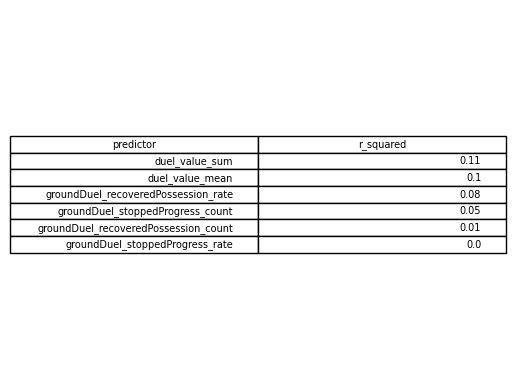

In [72]:
fig, ax = plt.subplots()
ax.axis('off')
ax.table(cellText=r_gc.values, colLabels=r_gc.columns, loc='center')
plt.savefig('figures/tables/season_gc_linear_pred.png', bbox_inches='tight', dpi=600)

In [44]:
bigWestMatches = matches[matches.competitionId == 43209][["wyId","seasonId"]]

In [45]:
bigWest_duel_values = pd.merge(bigWestMatches,defensive_duels[["matchId","player_name","duel_value","team_id"]],left_on="wyId",right_on="matchId",how="inner")

In [46]:
player_big_west_season_duel_values = bigWest_duel_values.groupby(["seasonId","player_name"]).agg({'team_id':'first','duel_value':"sum"}).reset_index()
player_big_west_season_duel_values_2025 = player_big_west_season_duel_values[player_big_west_season_duel_values.seasonId == 190927].sort_values(by="duel_value",ascending=False)

<Axes: >

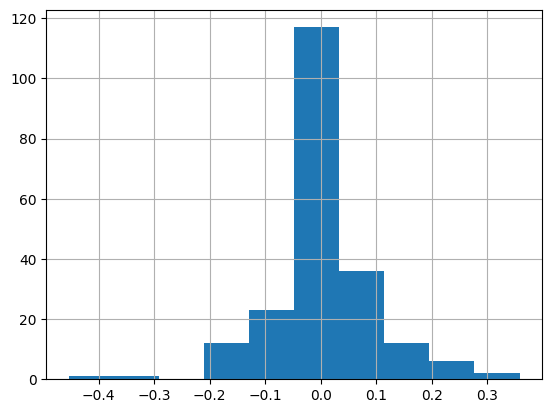

In [47]:
player_big_west_season_duel_values_2025["duel_value"].hist()

# UCSD has team id of 68155

In [48]:
team_big_west_season_duel_values = bigWest_duel_values.groupby(["seasonId","team_id"])[["duel_value"]].sum().reset_index()
team_big_west_season_duel_values[team_big_west_season_duel_values.seasonId==190927].sort_values(by="duel_value",ascending=False)

,seasonId,team_id,duel_value
30,190927,24424,1.155726
33,190927,24488,0.486107
31,190927,24426,0.407910
34,190927,24494,0.390510
38,190927,28356,0.368412
36,190927,28229,-0.020225
35,190927,28101,-0.068645
37,190927,28242,-0.118779
39,190927,68155,-0.232510
32,190927,24487,-0.735445
